In [81]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from graphviz import Source
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import cross_val_score, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [82]:
data = load_iris(as_frame=True)
display(data.data)
data.target

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [83]:
X = data.data.values
y = data.target
X, y

(array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
        [5

In [84]:
model = DecisionTreeClassifier(max_depth=17, random_state=67)
model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,17
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,67
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [85]:
data.data.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')

In [86]:
export_graphviz(model, out_file="iris_decision_tree.dot", rounded=True, filled=True, feature_names=data.data.columns, class_names=data.target_names)

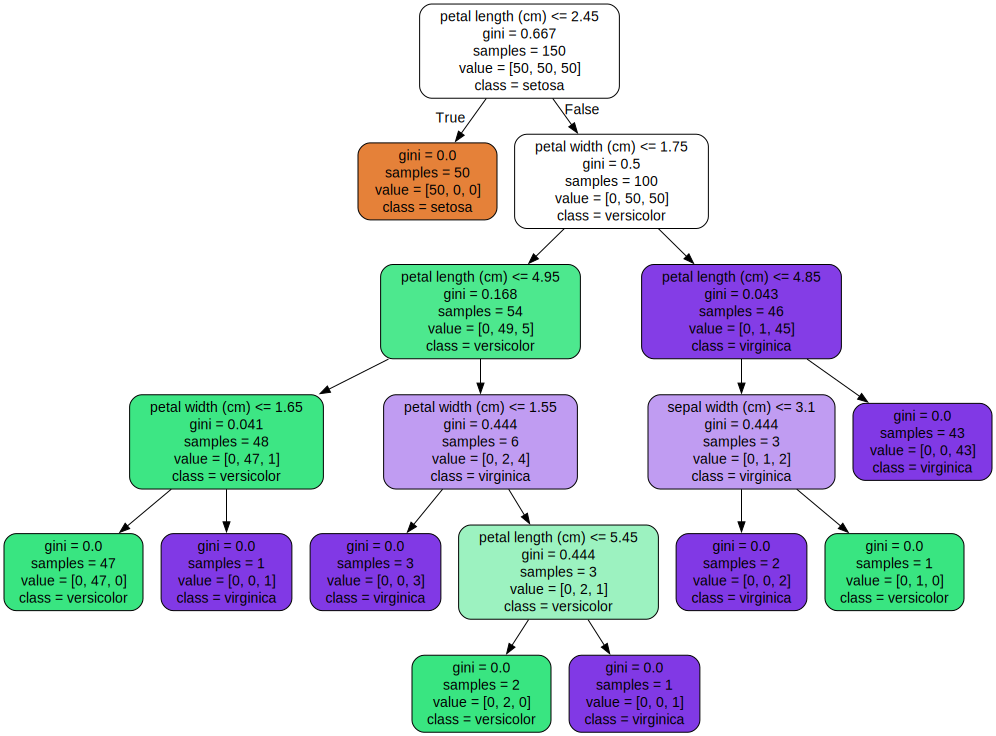

In [87]:
Source.from_file("iris_decision_tree.dot")

In [88]:
print(f"{cross_val_score(model, X, y, scoring="accuracy", cv=50).mean().round(5)*100}%")

95.333%


In [89]:
yPredictions = cross_val_predict(model, X, y, cv=50)

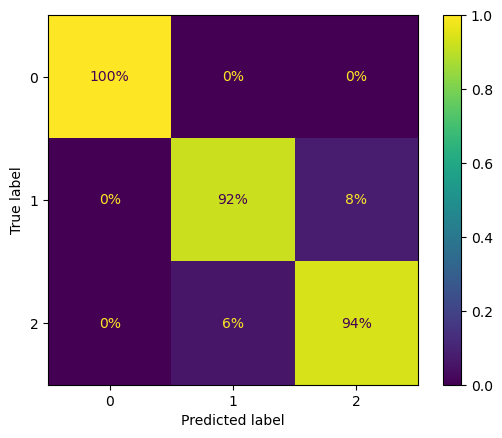

Overall Acuracy: 95.333%


In [90]:

ConfusionMatrixDisplay.from_predictions(y, yPredictions, normalize="true", values_format=".0%")
plt.show()
print(f"Overall Acuracy: {round(accuracy_score(y, yPredictions)*100, 3)}%")


In [91]:
params = {
    "max_depth" :np.arange(1, 18, 1)
}
search = RandomizedSearchCV(model, param_distributions=params, n_iter=17, random_state=67, cv=50, verbose=3, scoring="accuracy", n_jobs=-1, refit=True)
search.fit(X, y)

Fitting 50 folds for each of 17 candidates, totalling 850 fits
[CV 1/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 3/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 2/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 4/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 5/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 6/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 7/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 8/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 9/50] END ......................max_depth=1;, score=0.667 total time=   0.0s
[CV 10/50] END .....................max_depth=1;, score=0.667 total time=   0.0s
[CV 11/50] END .....................max_depth=1;, score=0.667 total time=   0.0s
[CV 12/50] END .....................max_depth=

,estimator,DecisionTreeC...ndom_state=67)
,param_distributions,"{'max_depth': array([ 1, 2..., 15, 16, 17])}"
,n_iter,17
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,50
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,67
,error_score,nan


In [92]:
resulrDF = pd.DataFrame(search.cv_results_).set_index("rank_test_score").sort_index()
resulrDF

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,split42_test_score,split43_test_score,split44_test_score,split45_test_score,split46_test_score,split47_test_score,split48_test_score,split49_test_score,mean_test_score,std_test_score
rank_test_score,,,,,,,,,,,,,,,,,,,,,
1,0.001080,0.000239,0.000673,0.000122,3,{'max_depth': 3},1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.960000,1.083205e-01
2,0.000999,0.000182,0.000683,0.000139,7,{'max_depth': 7},1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.001046,0.000295,0.000665,0.000143,6,{'max_depth': 6},1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.001348,0.000411,0.000868,0.000282,5,{'max_depth': 5},1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.000923,0.000196,0.000622,0.000133,8,{'max_depth': 8},1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.001241,0.000401,0.000820,0.000308,11,{'max_depth': 11},1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.001162,0.000121,0.000772,0.000069,10,{'max_depth': 10},1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.001106,0.000109,0.000746,0.000117,9,{'max_depth': 9},1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01
2,0.001225,0.000154,0.000808,0.000082,13,{'max_depth': 13},1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.953333,1.156623e-01


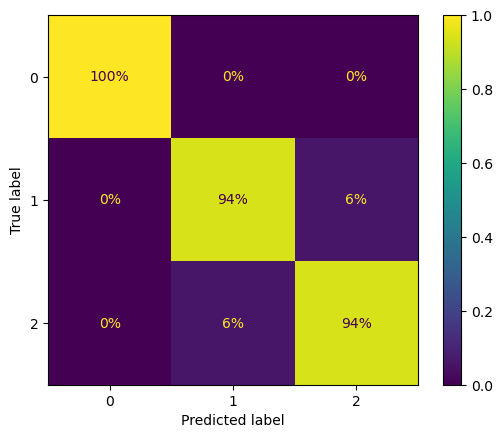

Overall Acuracy: 96.0%


In [93]:
finalModel = search.best_estimator_
yPredictions = cross_val_predict(finalModel, X, y, cv=50)
ConfusionMatrixDisplay.from_predictions(y, yPredictions, normalize="true", values_format=".0%")
plt.show()
print(f"Overall Acuracy: {round(accuracy_score(y, yPredictions)*100, 3)}%")

In [94]:
export_graphviz(finalModel, out_file="iris_decision_tree.dot", rounded=True, filled=True, feature_names=data.data.columns, class_names=data.target_names)

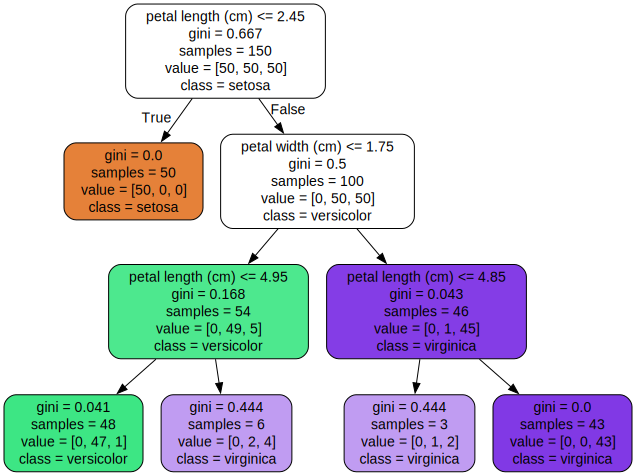

In [95]:
Source.from_file("iris_decision_tree.dot")